# Sélection de paramètres de régularisation après sélection et estimations des paramètres

Le but de notebook est de tester une nouvelle méthode pour sélectionner depuis une grille de valeur le paramètre de regularisation dans un contexte de selection de support avec la pénalisation LASOO.

In [1]:
import sdg4varselect.plot as sdgplt
import jax.numpy as jnp
import jax.random as jrd

### Dataset generation

First, let's generate a data set corresponding to a joint model of longitduinal logistic data and a Cox model.


$$ \left\{\begin{array}{rll}
            h(t|U_i) 
            &=h_{0}(t) \exp(\beta^T U_i + \alpha m(t,\varphi_i))
            \\ Y_{i,j} &= m(t_j; \varphi_i) + \varepsilon_{i,j}
            \\ \varphi_i \sim \mathcal N(\mu, \Gamma)   
            & ; ~\varepsilon_{i,j} \sim \mathcal N(0,\sigma^2).             
        \end{array}\right. ~ \forall i \in\{1,...,N\}, j\in\{1,...,J\}$$

where : $m(t_j; \varphi_i) = \frac{\varphi_{1,i}}{1+\exp\left(\frac{\varphi_{2,i}-t_j}{\varphi_{3,i}} \right)}$ and $h_{0}(t)= b a^{-b} t^{b-1}$ with $a=80$ and $b=35$

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


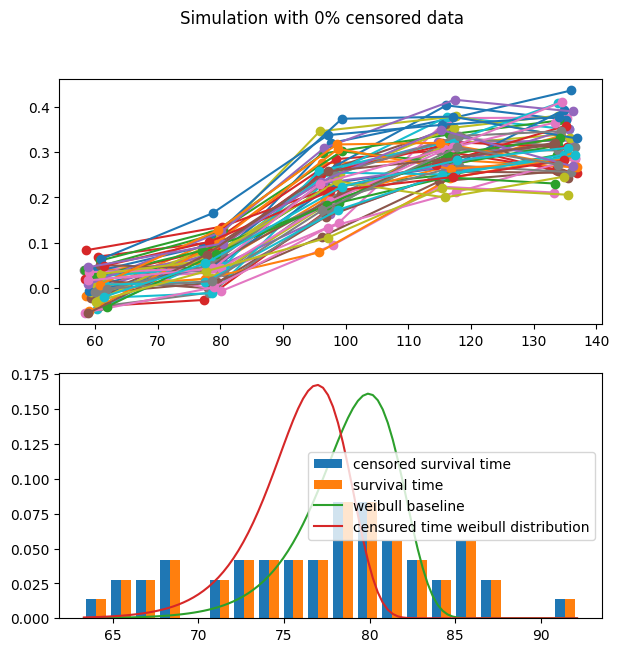

In [2]:
from sdg4varselect.logistic import Logistic_JM
from sdg4varselect.data_handler import DataHandler

model = Logistic_JM(N=50, J=5, DIM_HD=5)

# Simulation parameter
params_star = model.new_params(
    mu1=0.3,
    mu2=90.0,
    mu3=7.5,
    gamma2_1=0.0025,
    gamma2_2=20,
    sigma2=0.001,
    alpha=11.11,
    beta=jnp.concatenate([jnp.array([-2, -3, 3, 2]), jnp.zeros(shape=(model.DIM_HD-4,))] )
)

obs, sim = model.sample(params_star, jrd.PRNGKey(0), weibull_censoring_loc=7700)

dh = DataHandler()
dh.add_data(**obs)

_ = sdgplt.plot_sample(obs, sim, params_star, 77, 80, 35)

## Algorithm configuration

Initiation of the algorithm with accurate step size.
The algorithm will stop ater 2000 iteration or if the gradient value are less than 1e-3.

In [3]:
from sdg4varselect.algo import SPG_FIM

algo_settings = SPG_FIM.settings(
    step_size_grad={
        "learning_rate": 1e-8,
        "preheating": 400,
        "heating": 600,
        "max": 0.9,
    },
    step_size_approx_sto={
        "learning_rate": 1e-8,
        "preheating": 400,
        "heating": None,
        "max": 1,
    },
    step_size_fisher={
        "learning_rate": 1e-8,
        "preheating": 400,
        "heating": None,
        "max": 0.9,
    },
    max_iter=2000,
)

We use this function to perform an selection and estimatation for different regularization values.

In [4]:
import gzip
import pickle

R = pickle.load(gzip.open(f"new_reg_path.pkl.gz", "rb"))
lbd_set, reg_path = R["lbd_set"],R["reg_path"]



We can now compute de BIC criterion after the variable selection and after the estimation.

In [5]:
from sdg4varselect.algo import BIC

bic_selection = BIC(jnp.array([res[0].theta[-1, 7:] for res in reg_path]),
                     jnp.array([res[0].likelihood for res in reg_path]),
                     model.N*(model.J+1),
)
bic_estimation = BIC(jnp.array([res[1].theta[-1, 7:] for res in reg_path]),
                     jnp.array([res[1].likelihood for res in reg_path]),
                     model.N*(model.J+1),
)


AttributeError: 'str' object has no attribute 'theta'

In [ ]:
lbd_set =  10 ** jnp.linspace(-2, 0, num=2)

fig = sdgplt.figure()
ax = fig.add_subplot(2,1,1)
ax.set_xscale("log")
ax.plot(lbd_set, jnp.array([res[1].theta[-1, 7:] for res in reg_path]))
ax.set_title(f"Regularization path for N={model.N},P={model.DIM_HD},J={model.J}")

ax = fig.add_subplot(2,1,2)
ax.set_xscale("log")

ax.plot(lbd_set, bic_selection, color=f"C{5}", linewidth=2, linestyle="--", label="BIC selection")
ax.plot(lbd_set, bic_estimation, color=f"C{0}", linewidth=2, linestyle="--", label="BIC estimation")
ax.legend()

In [ ]:
_ = sdgplt.plot_theta([r[0] for r in reg_path], model.DIM_LD, params_star, model.params_names)
_ = sdgplt.plot_theta_HD([r[0] for r in reg_path], model.DIM_LD, params_star, model.params_names)

In [ ]:
_ = sdgplt.plot_theta([r[1] for r in reg_path], model.DIM_LD, params_star, model.params_names)
_ = sdgplt.plot_theta_HD([r[1] for r in reg_path], model.DIM_LD, params_star, model.params_names)

In [ ]:
[r[0].theta[-1] for r in reg_path]

In [ ]:
jnp.where(id)

In [ ]:
id

In [ ]:
jupyter nbconvert --execute --to html notebook.ipynb